<a href="https://colab.research.google.com/github/iztzx/introdatascience/blob/main/GA2_Data_Modelling_Leow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("Final_Merged_All.csv")

print(df.shape)
df.head()

(484114, 25)


,Date_Time,Year,Month,State_Code,State_Name,District_Code,District_Name,Place,Temperature,Pressure,...,UV_Index,Feel_Like_Temp,Visibility,Solar_Radiation,Pollutant_Value,Precipitation_Rate,Precipitation_Total,Monthly_Rainfall_Current_Month,Annual_Rainfall,Flood
0,2005-10-01 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,60.0,0.0,0.0,294.11,2631.0,0.0
1,2005-10-01 17:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,59.0,0.0,0.0,294.11,2631.0,0.0
2,2005-10-02 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,50.0,0.0,0.0,294.11,2631.0,0.0
3,2005-10-02 17:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,51.0,0.0,0.0,294.11,2631.0,0.0
4,2005-10-03 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,52.0,0.0,0.0,294.11,2631.0,0.0


In [ ]:
for col in df.columns:
    print(col)


Date_Time
Year
Month
State_Code
State_Name
District_Code
District_Name
Place
Temperature
Pressure
Dew_Point
Humidity
Wind_Speed
Gust
Wind_Chill
UV_Index
Feel_Like_Temp
Visibility
Solar_Radiation
Pollutant_Value
Precipitation_Rate
Precipitation_Total
Monthly_Rainfall_Current_Month
Annual_Rainfall
Flood


In [ ]:
df["Flood"].value_counts()

,count
Flood,
0.0,277101
1.0,207012


In [ ]:
df.isnull().sum()


,0
Date_Time,0
Year,0
Month,0
State_Code,0
State_Name,0
District_Code,0
District_Name,0
Place,1
Temperature,1
Pressure,1


In [ ]:
df = df.dropna()

print(df.shape)
print(df.isnull().sum())

(484113, 25)
Date_Time                         0
Year                              0
Month                             0
State_Code                        0
State_Name                        0
District_Code                     0
District_Name                     0
Place                             0
Temperature                       0
Pressure                          0
Dew_Point                         0
Humidity                          0
Wind_Speed                        0
Gust                              0
Wind_Chill                        0
UV_Index                          0
Feel_Like_Temp                    0
Visibility                        0
Solar_Radiation                   0
Pollutant_Value                   0
Precipitation_Rate                0
Precipitation_Total               0
Monthly_Rainfall_Current_Month    0
Annual_Rainfall                   0
Flood                             0
dtype: int64


In [ ]:
feature_cols = [
    "Year",
    "Month",
    "State_Code",
    "District_Code",
    "Temperature",
    "Pressure",
    "Dew_Point",
    "Humidity",
    "Wind_Speed",
    "Gust",
    "Wind_Chill",
    "UV_Index",
    "Feel_Like_Temp",
    "Visibility",
    "Solar_Radiation",
    "Pollutant_Value",
    "Precipitation_Rate",
    "Precipitation_Total",
    "Monthly_Rainfall_Current_Month",
    "Annual_Rainfall"
]

X = df[feature_cols]
y = df["Flood"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (484113, 20)
y shape: (484113,)
Flood
0.0    277101
1.0    207012
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (387290, 20)
X_test: (96823, 20)
y_train: (387290,)
y_test: (96823,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.71      0.72     55420
         1.0       0.63      0.68      0.65     41403

    accuracy                           0.69     96823
   macro avg       0.69      0.69      0.69     96823
weighted avg       0.70      0.69      0.69     96823



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000)
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.76      0.76     55420
         1.0       0.67      0.67      0.67     41403

    accuracy                           0.72     96823
   macro avg       0.71      0.71      0.71     96823
weighted avg       0.72      0.72      0.72     96823



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     55420
         1.0       1.00      1.00      1.00     41403

    accuracy                           1.00     96823
   macro avg       1.00      1.00      1.00     96823
weighted avg       1.00      1.00      1.00     96823



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     55420
         1.0       1.00      1.00      1.00     41403

    accuracy                           1.00     96823
   macro avg       1.00      1.00      1.00     96823
weighted avg       1.00      1.00      1.00     96823



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.720273,0.674218,0.669203,0.671701
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000


In [ ]:
print("Decision Tree training accuracy:", dt_model.score(X_train, y_train))
print("Decision Tree testing accuracy:", dt_model.score(X_test, y_test))

Decision Tree training accuracy: 1.0
Decision Tree testing accuracy: 1.0


In [ ]:
dt_model_limited = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model_limited.fit(X_train, y_train)

dt_limited_pred = dt_model_limited.predict(X_test)

print(classification_report(y_test, dt_limited_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     55420
         1.0       0.94      0.90      0.92     41403

    accuracy                           0.93     96823
   macro avg       0.93      0.93      0.93     96823
weighted avg       0.93      0.93      0.93     96823



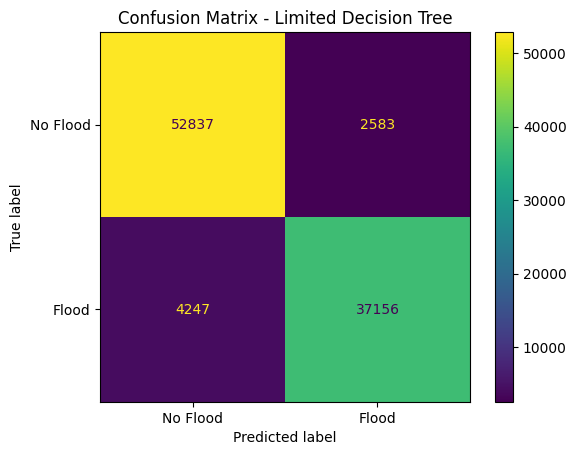

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, dt_limited_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Flood", "Flood"]
)

disp.plot()
plt.title("Confusion Matrix - Limited Decision Tree")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Limited Decision Tree": dt_limited_pred
}

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.720273,0.674218,0.669203,0.671701
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Limited Decision Tree,0.929459,0.935001,0.897423,0.915827


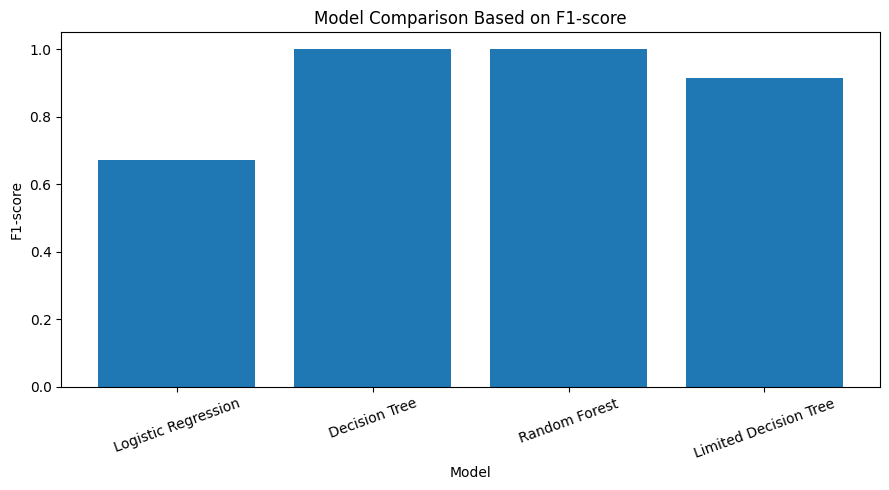

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dt_model_limited.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,Year,0.534588
19,Annual_Rainfall,0.305841
3,District_Code,0.158904
18,Monthly_Rainfall_Current_Month,0.000667
2,State_Code,0.000000
1,Month,0.000000
4,Temperature,0.000000
5,Pressure,0.000000
8,Wind_Speed,0.000000
9,Gust,0.000000


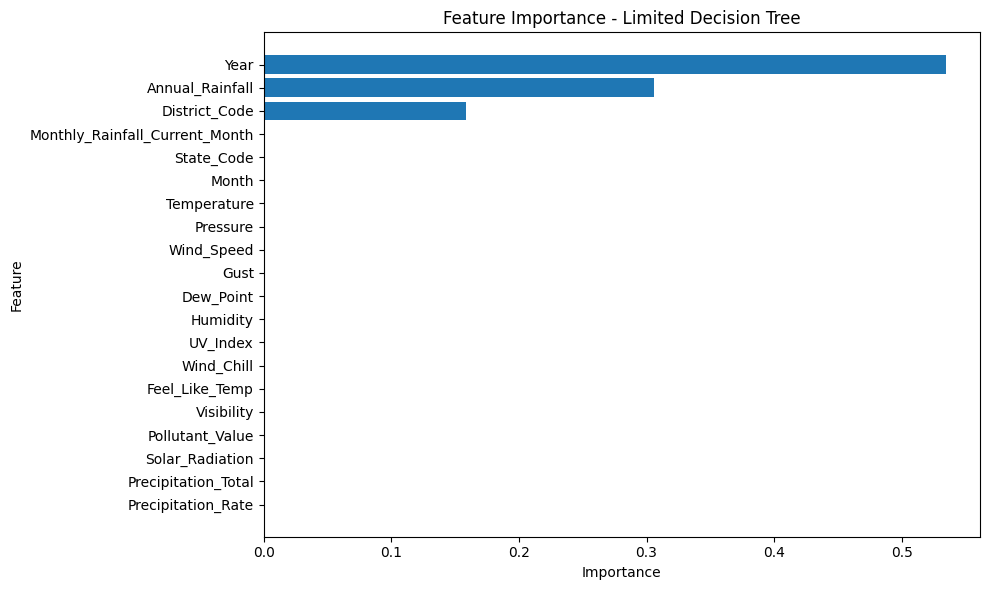

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Limited Decision Tree")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("feature_importance_limited_decision_tree.png", dpi=300, bbox_inches="tight")

plt.show()